# Importing the Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score

# Reading the Data

In [3]:
df = pd.read_csv('data/spotify_songs.csv')
df['index'] =df.index
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,index
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,0
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,2
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,3
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,4


In [4]:
df.isnull().sum()

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
index                       0
dtype: int64

In [5]:
df.shape

(32833, 24)

# Separating the Features

In [6]:
cat_columns = ['playlist_genre', 'playlist_subgenre', 'playlist_name', 'track_artist', 'track_album_name']

num_columns = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo']

In [7]:
encoders = {}
for col in cat_columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

In [8]:
scaler = StandardScaler()
df[num_columns] = scaler.fit_transform(df[num_columns])

In [9]:
df_processed = df[cat_columns + num_columns]

# Data Visualizations

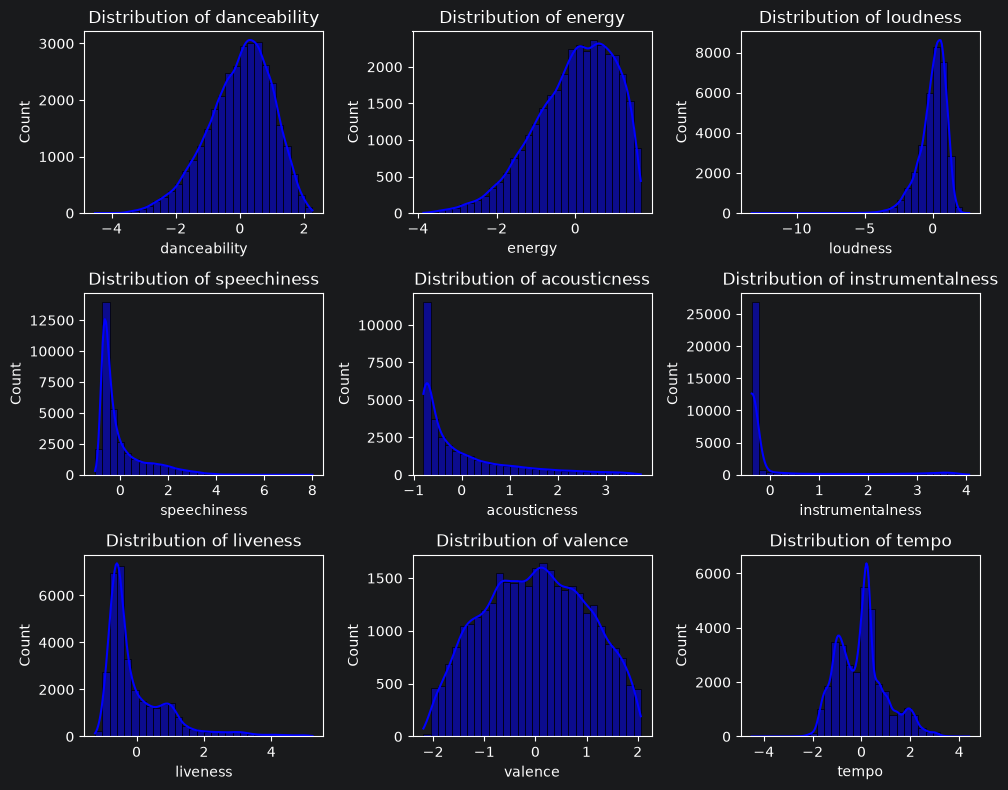

In [10]:
plt.figure(figsize=(10, 8))
for i, feature in enumerate(num_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], bins=30, kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

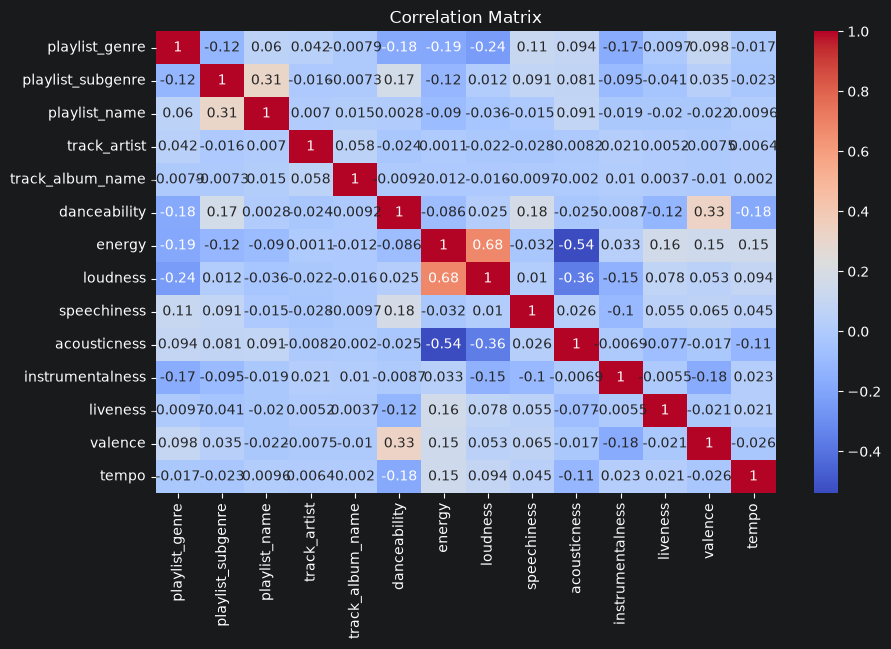

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_processed.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

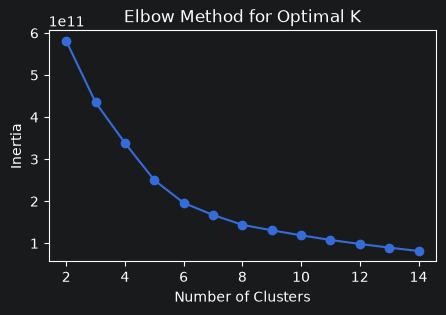

In [12]:
inertia = []
k_range = range(2, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_processed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [13]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_processed)

score = silhouette_score(df_processed, df['cluster'])
print(f'Silhouette Score: {score}')

Silhouette Score: 0.38875832924363934


# Cosine Similarity

In [14]:
similarity = cosine_similarity(df_processed)
print(similarity)
print(similarity.shape)

[[1.         0.98404079 0.430651   ... 0.98696487 0.99233626 0.99587274]
 [0.98404079 1.         0.58390086 ... 0.99985056 0.99846835 0.96412617]
 [0.430651   0.58390086 1.         ... 0.56981256 0.53879441 0.34750472]
 ...
 [0.98696487 0.99985056 0.56981256 ... 1.         0.99926777 0.96856444]
 [0.99233626 0.99846835 0.53879441 ... 0.99926777 1.         0.97715544]
 [0.99587274 0.96412617 0.34750472 ... 0.96856444 0.97715544 1.        ]]
(32833, 32833)


# Getting the Song from User

In [28]:
df['track_name'] = df['track_name'].astype(str)

track_name = input('Enter your favourite spotify song: ')
print(track_name)

Whatever It Takes



In [29]:
list_of_all_songs = df['track_name'].dropna().astype(str).tolist()

find_close_match = difflib.get_close_matches(track_name, list_of_all_songs)

close_match = find_close_match[0]

index_of_the_song = df[df.track_name == close_match]['index'].values[0]

# Finding the Similarity Score

In [30]:
similarity_score = list(enumerate(similarity[index_of_the_song]))

sorted_similar_songs = sorted(similarity_score, key = lambda x:x[1], reverse=True)

# Suggesting the Songs

In [31]:
print("Songs suggested for you : \n")

i = 1

for song in sorted_similar_songs[1:11]:
    index = song[0]
    title_of_the_song = df[df.index == index]['track_name'].values[0]
    if (i<11):
        print(i,'. ', title_of_the_song)
        i += 1

Songs suggested for you : 

1 .  Believer
2 .  Thunder
3 .  Thunder
4 .  GANG
5 .  Meant To Be
6 .  Kill For You
7 .  Live To Win
8 .  Flying High
9 .  Knast Oder Tod (remix feat. Dardan)
10 .  La solución (feat. Carlos Rivera)
